# Force Validation — Commanded vs Measured

## Multi-location Analysis

## Cell 1 — Load Data

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SESSION_DIR = "/home/sujith/Documents/NOARK_backbone/csv_data/pos_6"

lc  = pd.read_csv(os.path.join(SESSION_DIR, "loadcell.csv"), parse_dates=["timestamp"])
gui = pd.read_csv(os.path.join(SESSION_DIR, "gui.csv"),      parse_dates=["timestamp"])

lc  = lc.sort_values("timestamp").reset_index(drop=True)
gui = gui.sort_values("timestamp").reset_index(drop=True)

print("lc  rows:", len(lc))
print("gui rows:", len(gui))

if len(lc) < 2 or len(gui) < 2:
    raise ValueError("One or both CSV files are empty — check SESSION_DIR: " + SESSION_DIR)

# EMA filter to reduce load cell noise (tune alpha: lower = smoother, more lag)
EMA_ALPHA = 0.15
lc["Fx"] = lc["Fx"].ewm(alpha=EMA_ALPHA).mean()
lc["Fy"] = lc["Fy"].ewm(alpha=EMA_ALPHA).mean()

lc_hz  = len(lc)  / (lc["timestamp"].iloc[-1]  - lc["timestamp"].iloc[0]).total_seconds()
gui_hz = len(gui) / (gui["timestamp"].iloc[-1] - gui["timestamp"].iloc[0]).total_seconds()
print("loadcell : {:.1f} Hz  ({} rows)".format(lc_hz,  len(lc)))
print("gui      : {:.1f} Hz  ({} rows)".format(gui_hz, len(gui)))

lc  rows: 19852
gui rows: 10114
loadcell : 349.3 Hz  (19852 rows)
gui      : 178.0 Hz  (10114 rows)


## Cell 2 — Resample Both Streams to 100 Hz

In [21]:
from scipy.interpolate import interp1d

RESAMPLE_HZ = 100

# common reference point — relative seconds avoids float precision loss at Unix scale
t0    = min(lc["timestamp"].iloc[0], gui["timestamp"].iloc[0])
lc_t  = (lc["timestamp"]  - t0).dt.total_seconds().values
gui_t = (gui["timestamp"] - t0).dt.total_seconds().values

t_start = max(lc_t[0],  gui_t[0])
t_end   = min(lc_t[-1], gui_t[-1])
# subtract half a sample to guarantee t_grid never reaches t_end (avoids float overshoot)
t_grid     = np.arange(t_start, t_end - 0.5 / RESAMPLE_HZ, 1.0 / RESAMPLE_HZ)
timestamps = t0 + pd.to_timedelta(t_grid, unit="s")

# loadcell — linear (continuous sensor signal)
lc_new = {"timestamp": timestamps}
for col in ["Fx", "Fy"]:
    lc_new[col] = interp1d(lc_t, lc[col].values, kind="linear",
                           bounds_error=True)(t_grid)
lc = pd.DataFrame(lc_new)

# gui — previous-value hold (step-wise commanded values); Fx/Fz omitted, recomputed in cell-4
gui_new = {"timestamp": timestamps}
for col in ["magnitude", "direction"]:
    gui_new[col] = interp1d(gui_t, gui[col].values, kind="previous",
                            bounds_error=True)(t_grid)
gui = pd.DataFrame(gui_new)

print("loadcell : {} rows @ {} Hz".format(len(lc),  RESAMPLE_HZ))
print("gui      : {} rows @ {} Hz".format(len(gui), RESAMPLE_HZ))

loadcell : 5683 rows @ 100 Hz
gui      : 5683 rows @ 100 Hz


## Cell 3 — Merge and Compute Measured Magnitude & Direction

In [22]:
HOLD_TIME  = 2.0
STABLE_WIN = 1.0   # last 1 s of each step
NUM_MAGS   = 4     # number of magnitude levels per angle (5, 10, 15, 24)
ANGLE_STEPS = 7
NUM_STEPS  = ANGLE_STEPS * NUM_MAGS   # 28 total sweep steps (step 0 is pre-sweep)

lc_merge = lc[["timestamp", "Fx", "Fy"]].rename(
    columns={"Fx": "measured_Fx", "Fy": "measured_Fy"})

df = pd.merge_asof(gui[["timestamp", "magnitude", "direction"]],
                   lc_merge,
                   on="timestamp", direction="nearest")

# recompute given components from magnitude+direction — avoids 1-sample CSV sync glitch at transitions
df["given_Fx"] = df["magnitude"] * np.cos(np.radians(df["direction"]))
df["given_Fz"] = df["magnitude"] * np.sin(np.radians(df["direction"]))

df["measured_magnitude"] = np.sqrt(df["measured_Fx"]**2 + df["measured_Fy"]**2)
df["measured_direction"] = np.degrees(np.arctan2(df["measured_Fy"], df["measured_Fx"]))
df["t_sec"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

# detect actual command changes from the GUI data (zero-order hold → clean staircase)
cmd_change = (df["magnitude"].diff().abs() > 0.1) | (df["direction"].diff().abs() > 0.5)
cmd_change.iloc[0] = True  # first row starts step 0 (pre-sweep, magnitude=0)
df["step"] = (cmd_change.cumsum() - 1).astype(int)

# step 0 = pre-sweep; steps 1..NUM_STEPS = actual sweep steps
df = df[df["step"] <= NUM_STEPS].reset_index(drop=True)

# true time elapsed since the actual command fired
step_start_t = df.groupby("step")["t_sec"].transform("min")
df["t_in_step"] = df["t_sec"] - step_start_t

# truncate each step at HOLD_TIME (last step otherwise runs until end of log)
df = df[df["t_in_step"] <= HOLD_TIME].reset_index(drop=True)

# angle changes: only between actual sweep steps (exclude pre-sweep step 0 where magnitude=0)
dir_changed = (df["direction"].diff().abs() > 0.5) & (df["magnitude"].shift().fillna(0) > 0)
change_groups = dir_changed.cumsum()
angle_changes = (
    df[dir_changed]
    .groupby(change_groups[dir_changed])["t_sec"]
    .first()
    .values
)
print(f"Angle transitions: {len(angle_changes)}  at t = {np.round(angle_changes, 2)} s")

out_path = os.path.join(SESSION_DIR, "force_comparison.csv")
df.to_csv(out_path, index=False)
print("Saved {} rows -> {}".format(len(df), out_path))
df.head()

Angle transitions: 6  at t = [ 8.   16.   23.99 32.   40.   48.  ] s
Saved 5600 rows -> /home/sujith/Documents/NOARK_backbone/csv_data/pos_6/force_comparison.csv


,timestamp,magnitude,direction,measured_Fx,measured_Fy,given_Fx,given_Fz,measured_magnitude,measured_direction,t_sec,step,t_in_step
0,2026-06-22 16:00:39.825172000,5.0,-131.733572,0.289291,-0.100099,-3.328339,-3.731241,0.306119,-19.086359,0.00,0,0.00
1,2026-06-22 16:00:39.835172000,5.0,-131.733572,0.102670,-0.078194,-3.328339,-3.731241,0.129056,-37.293361,0.01,0,0.01
2,2026-06-22 16:00:39.845172000,5.0,-131.733572,-0.385272,0.032516,-3.328339,-3.731241,0.386642,175.175839,0.02,0,0.02
3,2026-06-22 16:00:39.855171999,5.0,-131.733572,-0.150705,0.017470,-3.328339,-3.731241,0.151715,173.387580,0.03,0,0.03
4,2026-06-22 16:00:39.865172000,5.0,-131.733572,0.080190,-0.035709,-3.328339,-3.731241,0.087781,-24.003403,0.04,0,0.04


## Cell 5 — Plot Given vs Measured Fx and Fy

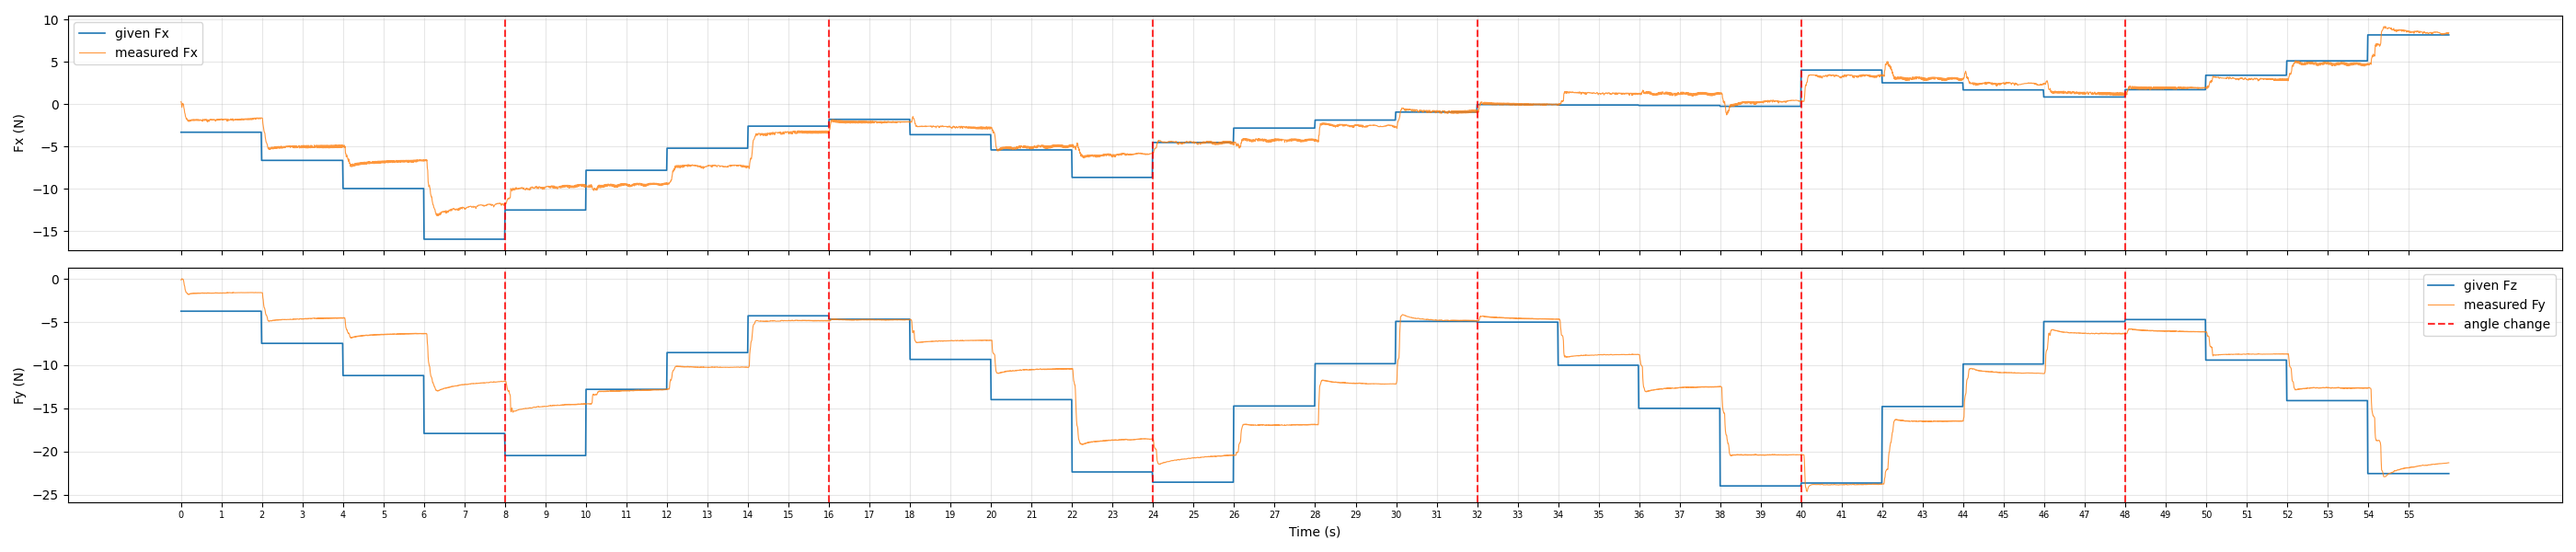

In [23]:
%matplotlib widget

fig, axes = plt.subplots(2, 1, figsize=(28, 6), sharex=True)

axes[0].plot(df["t_sec"], df["given_Fx"],    label="given Fx",    lw=1.2)
axes[0].plot(df["t_sec"], df["measured_Fx"], label="measured Fx", lw=0.8, alpha=0.8)
for t in angle_changes:
    axes[0].axvline(t, color="red", lw=1.5, ls="--", alpha=0.8)
axes[0].set_ylabel("Fx (N)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["t_sec"], df["given_Fz"],    label="given Fz",    lw=1.2)
axes[1].plot(df["t_sec"], df["measured_Fy"], label="measured Fy", lw=0.8, alpha=0.8)
for i, t in enumerate(angle_changes):
    axes[1].axvline(t, color="red", lw=1.5, ls="--", alpha=0.8,
                   label="angle change" if i == 0 else "")
axes[1].set_ylabel("Fy (N)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

t_max = int(df["t_sec"].max()) + 1
axes[1].set_xticks(range(0, t_max, 1))
axes[1].set_xticklabels(range(0, t_max, 1), fontsize=7)
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "fx_fz_timeseries.png"), dpi=150)
plt.show()

## Cell 6 — Plot Given vs Measured Magnitude and Direction

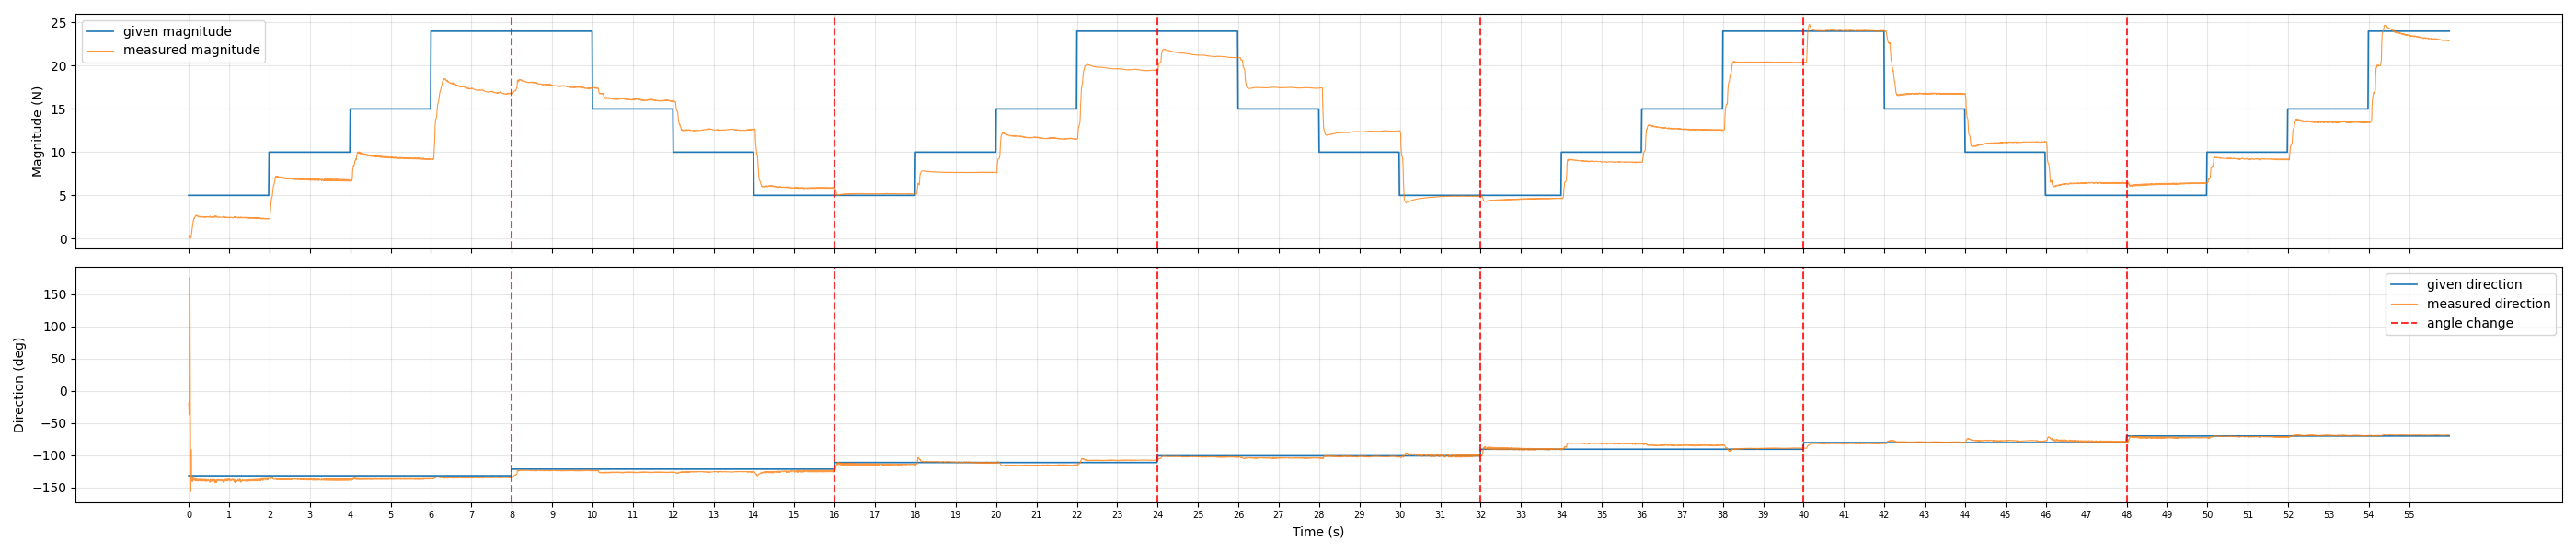

In [24]:
%matplotlib widget

fig, axes = plt.subplots(2, 1, figsize=(28, 6), sharex=True)

axes[0].plot(df["t_sec"], df["magnitude"],          label="given magnitude",    lw=1.2)
axes[0].plot(df["t_sec"], df["measured_magnitude"], label="measured magnitude", lw=0.8, alpha=0.8)
for t in angle_changes:
    axes[0].axvline(t, color="red", lw=1.5, ls="--", alpha=0.8)
axes[0].set_ylabel("Magnitude (N)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["t_sec"], df["direction"],          label="given direction",    lw=1.2)
axes[1].plot(df["t_sec"], df["measured_direction"], label="measured direction", lw=0.8, alpha=0.8)
for i, t in enumerate(angle_changes):
    axes[1].axvline(t, color="red", lw=1.5, ls="--", alpha=0.8,
                   label="angle change" if i == 0 else "")
axes[1].set_ylabel("Direction (deg)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

t_max = int(df["t_sec"].max()) + 1
axes[1].set_xticks(range(0, t_max, 1))
axes[1].set_xticklabels(range(0, t_max, 1), fontsize=7)
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "mag_dir_timeseries.png"), dpi=150)
plt.show()

## Cell 7 — Error Table per Step (Stable Window)

In [25]:
# stable window = last STABLE_WIN seconds of each step, excluding pre-sweep (magnitude=0)
stable = df[(df["t_in_step"] >= HOLD_TIME - STABLE_WIN) & (df["magnitude"] > 0)].copy()

print(f"Stable rows: {len(stable)}  (STABLE_WIN={STABLE_WIN}s, ~{round(STABLE_WIN*100)} rows/step)")
print(f"Steps in stable: {sorted(stable['step'].unique())}\n")

summary = stable.groupby("step").agg(
    angle     = ("direction",          "first"),
    given_mag = ("magnitude",          "first"),
    mean_meas = ("measured_magnitude", "mean"),
    mean_dir  = ("measured_direction", "mean"),
    n         = ("magnitude",          "count"),
).reset_index()
summary["mean_err"]    = summary["mean_meas"] - summary["given_mag"]
summary["dir_err"]     = summary["mean_dir"]  - summary["angle"]
summary["angle_group"] = (summary["angle"] != summary["angle"].shift()).cumsum()

# detect ascending vs descending magnitude within each angle group (zigzag sweep pattern)
def _sweep_direction(grp):
    mags = grp["given_mag"].values
    label = "ascending" if mags[-1] > mags[0] else "descending"
    return pd.Series([label] * len(grp), index=grp.index)

summary["sweep_dir"] = summary.groupby("angle_group", group_keys=False).apply(_sweep_direction)

print("{:>5} | {:>12} | {:>10} | {:>14} | {:>10} | {:>12} | {:>10} | {:>7} | {:>11}".format(
      "Step", "Angle (deg)", "Given (N)", "Meas Mag (N)", "Mag Err", "Meas Dir (°)", "Dir Err", "Samples", "Sweep Dir"))
print("-" * 115)
for i, (_, row) in enumerate(summary.iterrows()):
    if i > 0 and row["angle_group"] != summary["angle_group"].iloc[i - 1]:
        print()
    print("{:>5} | {:>12.1f} | {:>10.1f} | {:>14.3f} | {:>10.3f} | {:>12.1f} | {:>10.3f} | {:>7} | {:>11}".format(
          int(row["step"]), row["angle"], row["given_mag"], row["mean_meas"],
          row["mean_err"], row["mean_dir"], row["dir_err"], int(row["n"]), row["sweep_dir"]))

# save combined
err_csv = os.path.join(SESSION_DIR, "error_table.csv")
summary.to_csv(err_csv, index=False)
print(f"\nError table saved -> {err_csv}")

# save ascending and descending separately
asc_csv  = os.path.join(SESSION_DIR, "error_table_ascending.csv")
desc_csv = os.path.join(SESSION_DIR, "error_table_descending.csv")
summary[summary["sweep_dir"] == "ascending"].to_csv(asc_csv,  index=False)
summary[summary["sweep_dir"] == "descending"].to_csv(desc_csv, index=False)
print(f"Ascending  ({(summary['sweep_dir']=='ascending').sum()} steps) -> {asc_csv}")
print(f"Descending ({(summary['sweep_dir']=='descending').sum()} steps) -> {desc_csv}")

Stable rows: 2800  (STABLE_WIN=1.0s, ~100 rows/step)
Steps in stable: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]

 Step |  Angle (deg) |  Given (N) |   Meas Mag (N) |    Mag Err | Meas Dir (°) |    Dir Err | Samples |   Sweep Dir
-------------------------------------------------------------------------------------------------------------------
    0 |       -131.7 |        5.0 |          2.393 |     -2.607 |       -138.5 |     -6.726 |      99 |   ascending
    1 |       -131.7 |       10.0 |          6.786 |     -3.214 |       -137.8 |     -6.063 |     101 |   ascending
    2 |       -131.7 |       15.0 |          9.282 |     -5.718 |       -136.7 |     -4.947 |     100 |   ascending
    3 |       -131.7 |       24.0 |         16.990 |     -7.010 |       -134.9 |     -3.155 |     100 |   ascending

    4 |       -121.5 |       24.0 |         17.548 |     -6.452 |       -123.7 |     -2.226 |     100 |  descending
    5 |      

In [26]:
# targets = pd.read_csv(os.path.join(SESSION_DIR, "sweep_targets.csv"), parse_dates=["timestamp"])
# targets["t_cmd"] = (targets["timestamp"] - targets["timestamp"].iloc[0]).dt.total_seconds()
# targets["expected_t"] = targets["step"] * HOLD_TIME
# targets["drift_ms"] = (targets["t_cmd"] - targets["expected_t"]) * 1000
# print(targets[["step", "t_cmd", "expected_t", "drift_ms"]].to_string(index=False))
# print(f"\nMax drift: {targets['drift_ms'].abs().max():.1f} ms  (step {targets['drift_ms'].abs().idxmax()})")
# print(f"Mean drift: {targets['drift_ms'].mean():.1f} ms")

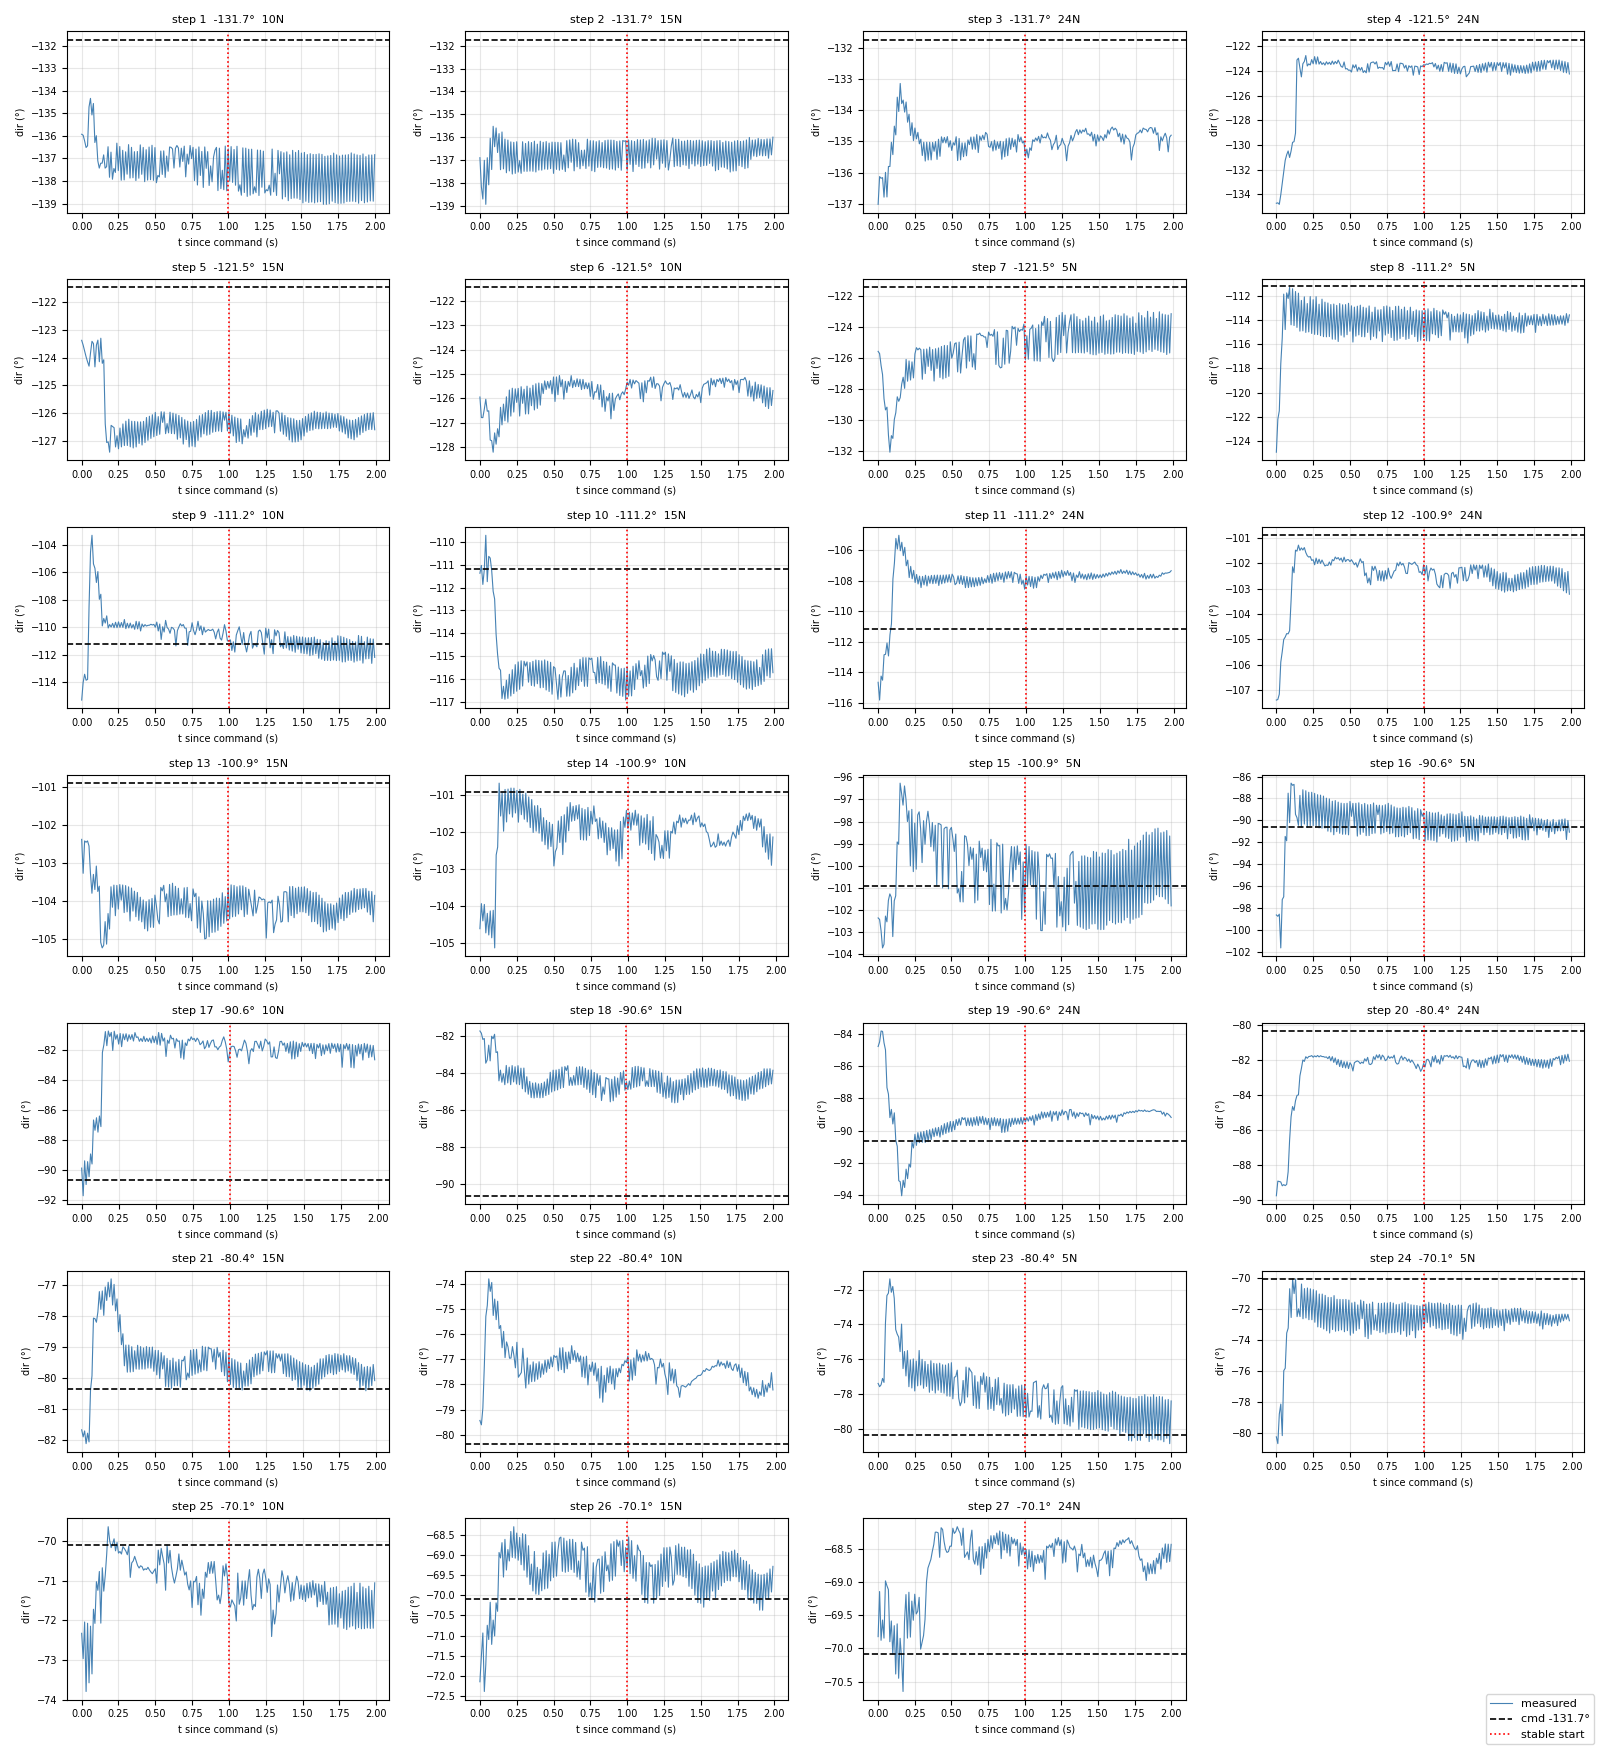

In [27]:
%matplotlib widget

step_ids = sorted(s for s in df["step"].unique() if s > 0)
ncols = 4
nrows = (len(step_ids) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.5), sharey=False)
axes = axes.flatten()

for ax, step_id in zip(axes, step_ids):
    chunk = df[df["step"] == step_id].copy()
    cmd_dir = chunk["direction"].iloc[0]
    mag = chunk["magnitude"].iloc[0]

    ax.plot(chunk["t_in_step"], chunk["measured_direction"], lw=0.8, color="steelblue", label="measured")
    ax.axhline(cmd_dir, color="black", lw=1.2, ls="--", label=f"cmd {cmd_dir:.1f}°")
    ax.axvline(HOLD_TIME - STABLE_WIN, color="red", lw=1.2, ls=":", label="stable start")

    ax.set_title(f"step {step_id}  {cmd_dir:.1f}°  {mag:.0f}N", fontsize=8)
    ax.set_xlabel("t since command (s)", fontsize=7)
    ax.set_ylabel("dir (°)", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for ax in axes[len(step_ids):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "settling_diagnostic.png"), dpi=150)
plt.show()

In [28]:
# mask = (df["t_sec"] >= df.loc[df["step"] == 8, "t_sec"].min() - 0.5) & \
#        (df["t_sec"] <= df.loc[df["step"] == 8, "t_sec"].max() + 0.5)
# chunk = df[mask]

# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(chunk["t_sec"], chunk["magnitude"],          label="given mag",    lw=1.5)
# ax.plot(chunk["t_sec"], chunk["measured_magnitude"], label="measured mag", lw=1.0)
# ax.axhline(10, color="green", ls="--", lw=1, label="10N target")
# ax.set_xlabel("Time (s)"); ax.set_ylabel("Magnitude (N)")
# ax.legend(); ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(os.path.join(SESSION_DIR, "step_zoom.png"), dpi=150)
# plt.show()

## Cell 8 — Error Bar Chart per Step

In [29]:
# mag_colors = {5.0: "#4c9be8", 10.0: "#f5a623", 15.0: "#7ed321", 24.0: "#e05252"}

# stable["err_magnitude"] = stable["measured_magnitude"] - stable["magnitude"]

# box_data   = []
# box_labels = []
# box_colors = []
# sep_positions = []

# for i, (_, row) in enumerate(summary.iterrows()):
#     errs = stable.loc[stable["step"] == row["step"], "err_magnitude"].values
#     box_data.append(errs)
#     box_labels.append("{:.0f}° / {:.0f}N".format(row["angle"], row["given_mag"]))
#     box_colors.append(mag_colors.get(round(row["given_mag"]), "grey"))
#     if i > 0 and row["angle_group"] != summary["angle_group"].iloc[i - 1]:
#         sep_positions.append(i + 0.5)

# fig, ax = plt.subplots(figsize=(16, 5))
# bp = ax.boxplot(box_data, patch_artist=True, widths=0.6,
#                 medianprops=dict(color="black", lw=2))
# for patch, color in zip(bp["boxes"], box_colors):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.8)

# ax.axhline(0, color="black", lw=1.0)
# for x in sep_positions:
#     ax.axvline(x, color="red", lw=1.0, ls="--", alpha=0.6)

# ax.set_xticks(range(1, len(box_labels) + 1))
# ax.set_xticklabels(box_labels, fontsize=7, rotation=45, ha="right")
# ax.set_ylabel("Error (N)  [measured − commanded]")
# ax.set_title("Force Magnitude Error Distribution per Step")
# ax.grid(True, axis="y", alpha=0.3)

# from matplotlib.patches import Patch
# legend = [Patch(color=c, label="{:.0f} N".format(m)) for m, c in mag_colors.items()]
# ax.legend(handles=legend, title="Commanded Mag", loc="upper right")
# plt.tight_layout()
# plt.savefig(os.path.join(SESSION_DIR, "error_boxplot.png"), dpi=150)
# plt.show()

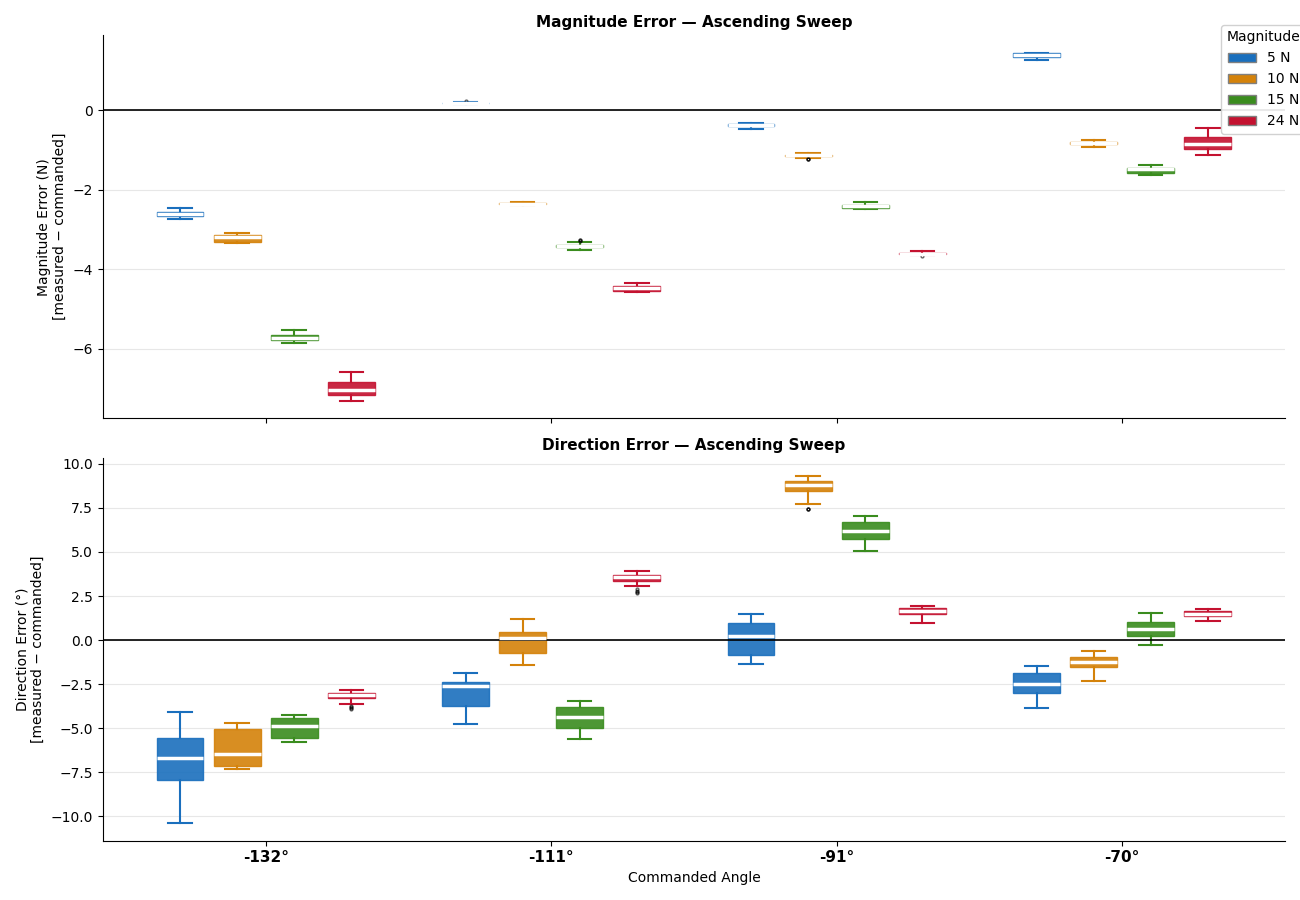

In [30]:
%matplotlib widget

asc_steps  = summary[summary["sweep_dir"] == "ascending"]["step"].values
stable_asc = stable[stable["step"].isin(asc_steps)].copy()
stable_asc = stable_asc.merge(
    summary[["step", "angle", "given_mag", "sweep_dir"]], on="step", how="left"
)
stable_asc["mag_err"] = stable_asc["measured_magnitude"] - stable_asc["given_mag"]
stable_asc["dir_err"] = stable_asc["measured_direction"] - stable_asc["direction"]

mag_levels = sorted(stable_asc["given_mag"].unique())
angles_asc = sorted(stable_asc["angle"].unique())

# stronger, more distinct colors
mag_colors = {5.0: "#1a6fbd", 10.0: "#d4820a", 15.0: "#3a8c1e", 24.0: "#c41230"}

n_angles = len(angles_asc)
n_mags   = len(mag_levels)
group_w  = 1.0
bar_w    = group_w / (n_mags + 1)
offsets  = np.linspace(-(n_mags - 1) / 2, (n_mags - 1) / 2, n_mags) * bar_w
x_pos    = np.arange(n_angles)

fig, (ax_mag, ax_dir) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

def draw_boxes(ax, data_col):
    for i, mag in enumerate(mag_levels):
        color = mag_colors[mag]
        for j, angle in enumerate(angles_asc):
            data = stable_asc[
                (stable_asc["given_mag"] == mag) &
                (stable_asc["angle"].round(1) == round(angle, 1))
            ][data_col].values
            xc = x_pos[j] + offsets[i]
            bp = ax.boxplot(data, positions=[xc], widths=bar_w * 0.82,
                            patch_artist=True, manage_ticks=False,
                            medianprops=dict(color="white", lw=2.5),
                            whiskerprops=dict(color=color, lw=1.5),
                            capprops=dict(color=color, lw=1.5),
                            flierprops=dict(marker=".", color=color, alpha=0.6, ms=4),
                            boxprops=dict(facecolor=color, color=color, alpha=0.9))

draw_boxes(ax_mag, "mag_err")
draw_boxes(ax_dir, "dir_err")

for ax, title, ylabel in [
    (ax_mag, "Magnitude Error — Ascending Sweep", "Magnitude Error (N)\n[measured − commanded]"),
    (ax_dir, "Direction Error — Ascending Sweep",  "Direction Error (°)\n[measured − commanded]"),
]:
    ax.axhline(0, color="black", lw=1.2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

ax_dir.set_xticks(x_pos)
ax_dir.set_xticklabels([f"{a:.0f}°" for a in angles_asc], fontsize=11, fontweight="bold")
ax_dir.set_xlabel("Commanded Angle", fontsize=10)

from matplotlib.patches import Patch
legend = [Patch(facecolor=mag_colors[m], edgecolor="grey", label=f"{m:.0f} N") for m in mag_levels]
fig.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.01, 0.98),
           fontsize=10, title="Magnitude", framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "boxplot_ascending.png"), dpi=150, bbox_inches="tight")
plt.show()

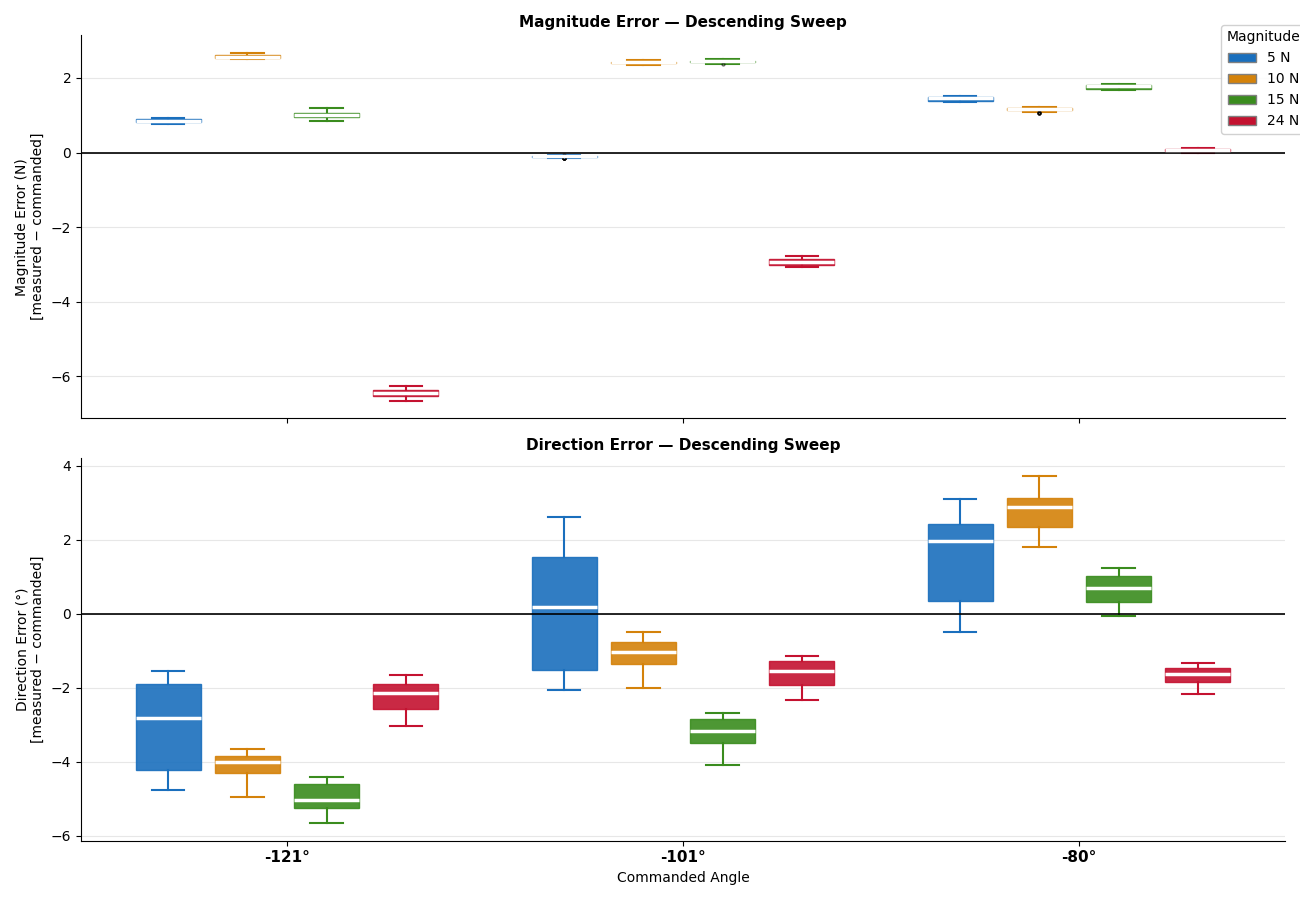

In [31]:
%matplotlib widget

desc_steps  = summary[summary["sweep_dir"] == "descending"]["step"].values
stable_desc = stable[stable["step"].isin(desc_steps)].copy()
stable_desc = stable_desc.merge(
    summary[["step", "angle", "given_mag", "sweep_dir"]], on="step", how="left"
)
stable_desc["mag_err"] = stable_desc["measured_magnitude"] - stable_desc["given_mag"]
stable_desc["dir_err"] = stable_desc["measured_direction"] - stable_desc["direction"]

mag_levels  = sorted(stable_desc["given_mag"].unique())
angles_desc = sorted(stable_desc["angle"].unique())

mag_colors = {5.0: "#1a6fbd", 10.0: "#d4820a", 15.0: "#3a8c1e", 24.0: "#c41230"}

n_angles = len(angles_desc)
n_mags   = len(mag_levels)
group_w  = 1.0
bar_w    = group_w / (n_mags + 1)
offsets  = np.linspace(-(n_mags - 1) / 2, (n_mags - 1) / 2, n_mags) * bar_w
x_pos    = np.arange(n_angles)

fig, (ax_mag, ax_dir) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

def draw_boxes_desc(ax, data_col):
    for i, mag in enumerate(mag_levels):
        color = mag_colors[mag]
        for j, angle in enumerate(angles_desc):
            data = stable_desc[
                (stable_desc["given_mag"] == mag) &
                (stable_desc["angle"].round(1) == round(angle, 1))
            ][data_col].values
            xc = x_pos[j] + offsets[i]
            ax.boxplot(data, positions=[xc], widths=bar_w * 0.82,
                       patch_artist=True, manage_ticks=False,
                       medianprops=dict(color="white", lw=2.5),
                       whiskerprops=dict(color=color, lw=1.5),
                       capprops=dict(color=color, lw=1.5),
                       flierprops=dict(marker=".", color=color, alpha=0.6, ms=4),
                       boxprops=dict(facecolor=color, color=color, alpha=0.9))

draw_boxes_desc(ax_mag, "mag_err")
draw_boxes_desc(ax_dir, "dir_err")

for ax, title, ylabel in [
    (ax_mag, "Magnitude Error — Descending Sweep", "Magnitude Error (N)\n[measured − commanded]"),
    (ax_dir, "Direction Error — Descending Sweep",  "Direction Error (°)\n[measured − commanded]"),
]:
    ax.axhline(0, color="black", lw=1.2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

ax_dir.set_xticks(x_pos)
ax_dir.set_xticklabels([f"{a:.0f}°" for a in angles_desc], fontsize=11, fontweight="bold")
ax_dir.set_xlabel("Commanded Angle", fontsize=10)

from matplotlib.patches import Patch
legend = [Patch(facecolor=mag_colors[m], edgecolor="grey", label=f"{m:.0f} N") for m in mag_levels]
fig.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.01, 0.98),
           fontsize=10, title="Magnitude", framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "boxplot_descending.png"), dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# %matplotlib widget
# import glob

# BASE_DIR = "/home/sujith/Documents/NOARK_backbone/csv_data"

# # collect all sessions that have both position.csv and error_table.csv
# records = []
# for pos_dir in sorted(glob.glob(os.path.join(BASE_DIR, "pos_*"))):
#     pos_file = os.path.join(pos_dir, "position.csv")
#     err_file = os.path.join(pos_dir, "error_table.csv")
#     if not (os.path.exists(pos_file) and os.path.exists(err_file)):
#         continue
#     pos  = pd.read_csv(pos_file)
#     errs = pd.read_csv(err_file)
#     x_m, z_m = pos["x"].iloc[0], pos["z"].iloc[0]
#     session   = os.path.basename(pos_dir)
#     for _, row in errs.iterrows():
#         records.append({
#             "session":   session,
#             "x":         x_m,
#             "z":         z_m,
#             "given_mag": row["given_mag"],
#             "mag_err":   row["mean_err"],
#             "dir_err":   row["dir_err"],
#             "sweep_dir": row.get("sweep_dir", "unknown"),
#         })

# spatial = pd.DataFrame(records)
# print(f"Loaded {len(spatial)} step records from {spatial['session'].nunique()} sessions")
# print(spatial.groupby("session")[["x","z"]].first().to_string())

# mag_levels = sorted(spatial["given_mag"].unique())
# mag_colors = {5.0: "#1a6fbd", 10.0: "#d4820a", 15.0: "#3a8c1e", 24.0: "#c41230"}

# fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# for ax, err_col, title, unit in [
#     (axes[0], "mag_err", "Magnitude Error",  "N"),
#     (axes[1], "dir_err", "Direction Error",  "°"),
# ]:
#     for mag in mag_levels:
#         sub = spatial[spatial["given_mag"] == mag].groupby(["x","z"]).agg(
#             mean_err=(err_col, "mean")
#         ).reset_index()

#         sc = ax.scatter(sub["x"] * 100, sub["z"] * 100,
#                         c=sub["mean_err"], cmap="RdYlGn_r",
#                         s=180, marker="o", edgecolors=mag_colors[mag],
#                         linewidths=2.5, alpha=0.85,
#                         vmin=spatial[err_col].min(), vmax=spatial[err_col].max(),
#                         label=f"{mag:.0f} N")

#         # label each point with the error value
#         for _, row in sub.iterrows():
#             ax.text(row["x"]*100 + 0.8, row["z"]*100 + 0.8,
#                     f"{row['mean_err']:+.2f}{unit}", fontsize=7.5, color="black")

#     ax.axhline(0, color="grey", lw=0.8, ls="--", alpha=0.5)
#     ax.axvline(0, color="grey", lw=0.8, ls="--", alpha=0.5)
#     ax.set_xlabel("X position (cm)", fontsize=11)
#     ax.set_ylabel("Z position (cm)", fontsize=11)
#     ax.set_title(f"Workspace {title} Map\n(mean {err_col} per position)", fontsize=11, fontweight="bold")
#     ax.grid(True, alpha=0.25)
#     ax.spines[["top","right"]].set_visible(False)
#     plt.colorbar(sc, ax=ax, label=f"Mean error ({unit})", shrink=0.8)

# from matplotlib.lines import Line2D
# legend = [Line2D([0],[0], marker="o", color="w", markerfacecolor=mag_colors[m],
#                  markeredgecolor=mag_colors[m], markersize=9, label=f"{m:.0f} N")
#           for m in mag_levels]
# fig.legend(handles=legend, loc="lower center", ncol=4, fontsize=10,
#            title="Magnitude", bbox_to_anchor=(0.5, -0.04))

# plt.suptitle("Spatial Error Map across Workspace Positions", fontsize=13, fontweight="bold")
# plt.tight_layout()
# plt.savefig(os.path.join(BASE_DIR, "spatial_error_map.png"), dpi=150, bbox_inches="tight")
# plt.show()

  loaded pos_1
  loaded pos_2
  loaded pos_3
  loaded pos_4
  loaded pos_5
  loaded pos_6

6 sessions  |  16750 samples
Saved → /home/sujith/Documents/NOARK_backbone/csv_data/fig_ascending_direction_error.png


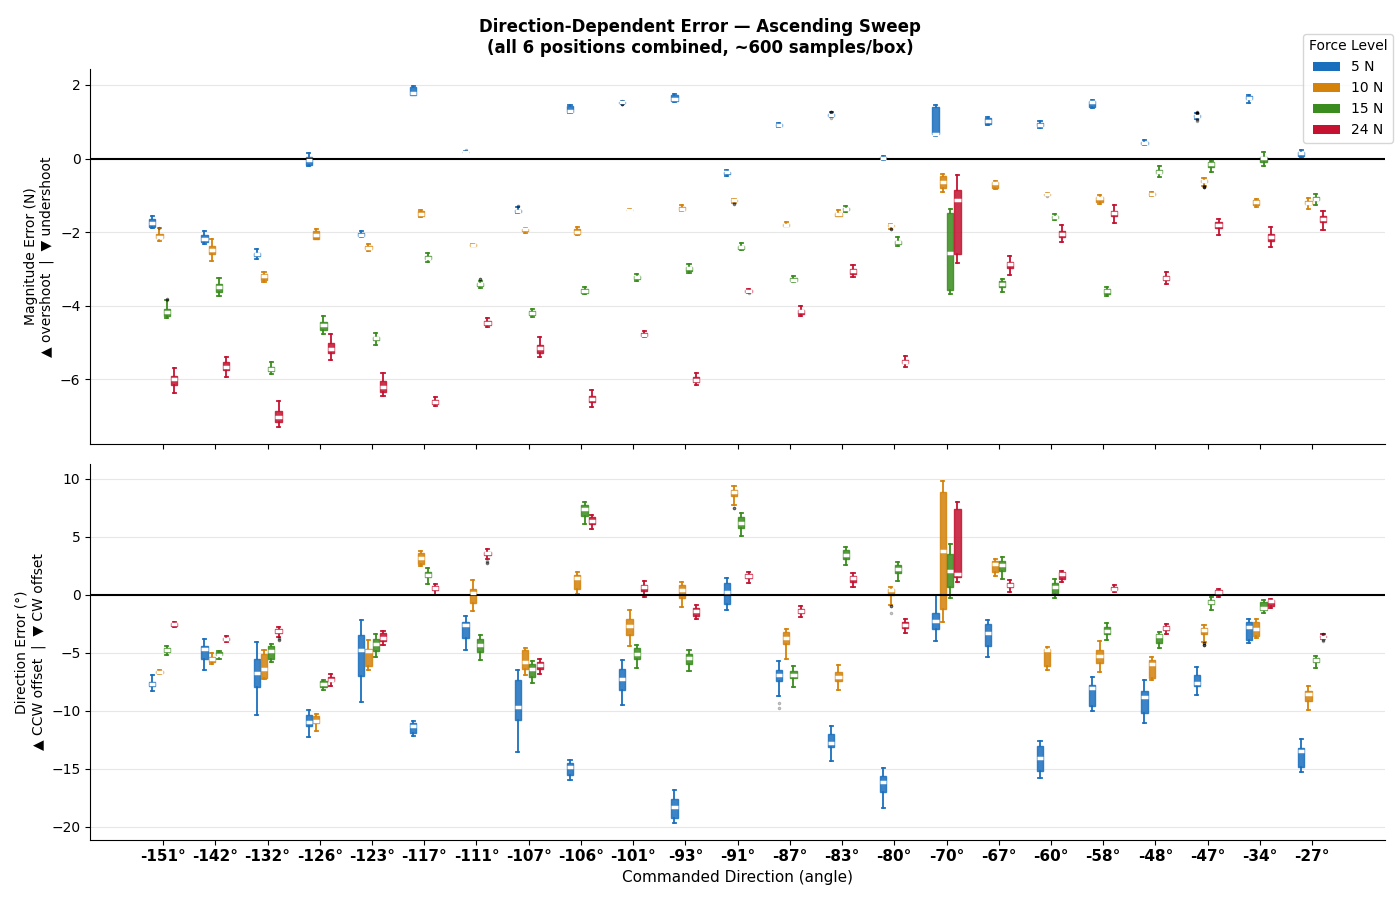

/tmp/ipykernel_4411/1843508868.py:91: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)


Saved → /home/sujith/Documents/NOARK_backbone/csv_data/fig_descending_direction_error.png


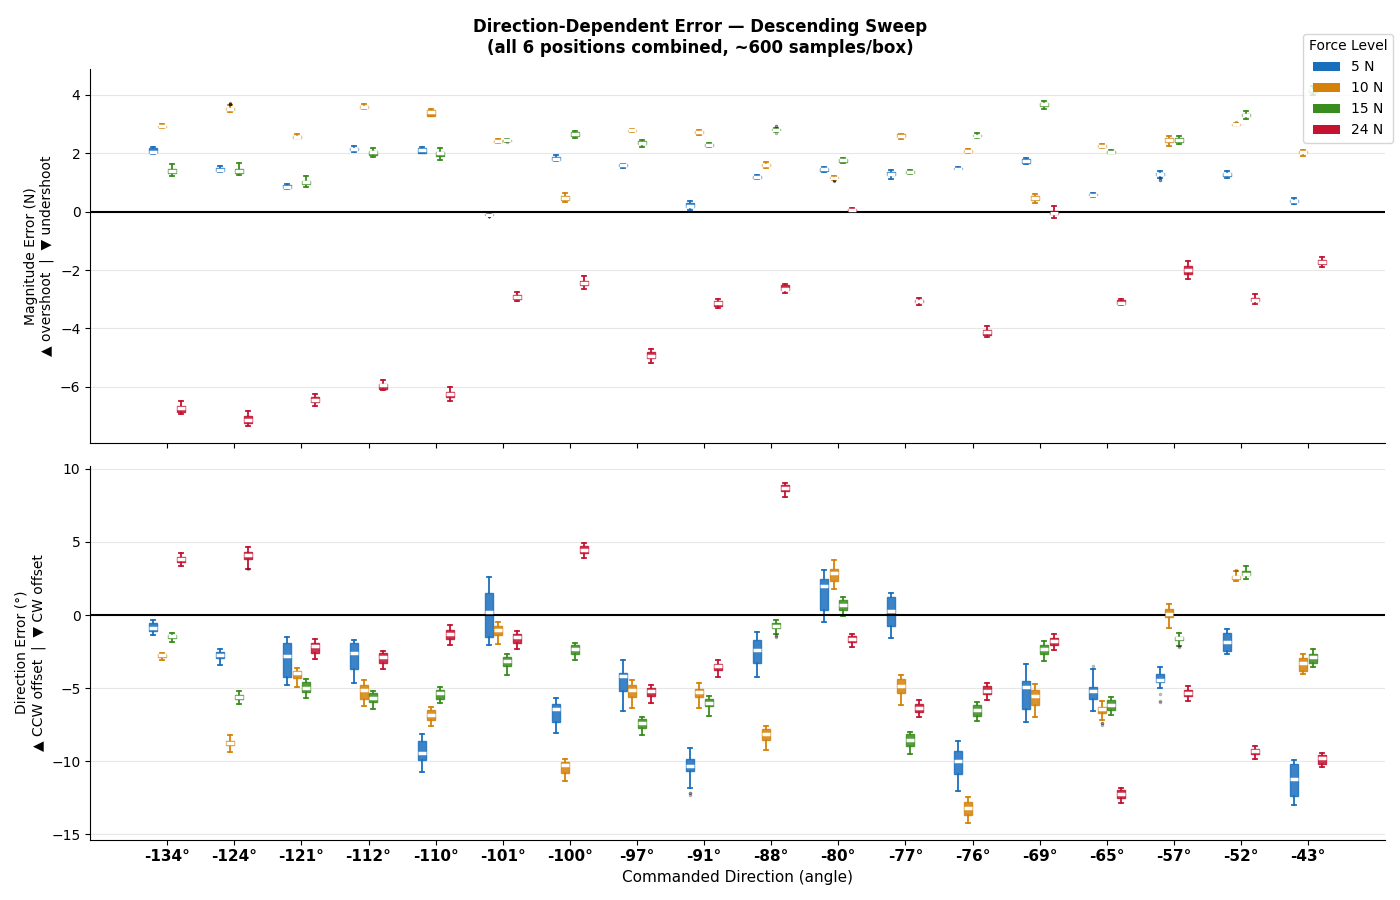

In [33]:
%matplotlib widget
import glob
from scipy.interpolate import interp1d
from matplotlib.patches import Patch

BASE_DIR    = "/home/sujith/Documents/NOARK_backbone/csv_data"
RESAMPLE_HZ = 100
HOLD_TIME   = 2.0
STABLE_WIN  = 1.0
NUM_STEPS   = 28
EMA_ALPHA   = 0.15
mag_colors  = {5.0: "#1a6fbd", 10.0: "#d4820a", 15.0: "#3a8c1e", 24.0: "#c41230"}

# ── load + pipeline for one session ──────────────────────────────────────────
def load_session(pos_dir):
    session  = os.path.basename(pos_dir)
    lc  = pd.read_csv(os.path.join(pos_dir, "loadcell.csv"),  parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    gui = pd.read_csv(os.path.join(pos_dir, "gui.csv"),       parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    lc["Fx"] = lc["Fx"].ewm(alpha=EMA_ALPHA).mean()
    lc["Fy"] = lc["Fy"].ewm(alpha=EMA_ALPHA).mean()

    t0    = min(lc["timestamp"].iloc[0], gui["timestamp"].iloc[0])
    lc_t  = (lc["timestamp"]  - t0).dt.total_seconds().values
    gui_t = (gui["timestamp"] - t0).dt.total_seconds().values
    t_grid = np.arange(max(lc_t[0], gui_t[0]),
                       min(lc_t[-1], gui_t[-1]) - 0.5/RESAMPLE_HZ,
                       1.0/RESAMPLE_HZ)
    ts = t0 + pd.to_timedelta(t_grid, unit="s")

    lc_r  = pd.DataFrame({"timestamp": ts,
                           "Fx": interp1d(lc_t, lc["Fx"].values)(t_grid),
                           "Fy": interp1d(lc_t, lc["Fy"].values)(t_grid)})
    gui_r = pd.DataFrame({"timestamp": ts,
                           "magnitude": interp1d(gui_t, gui["magnitude"].values, kind="previous")(t_grid),
                           "direction": interp1d(gui_t, gui["direction"].values,  kind="previous")(t_grid)})

    df = pd.merge_asof(gui_r, lc_r.rename(columns={"Fx":"mFx","Fy":"mFy"}),
                       on="timestamp", direction="nearest")
    df["meas_mag"] = np.sqrt(df["mFx"]**2 + df["mFy"]**2)
    df["meas_dir"] = np.degrees(np.arctan2(df["mFy"], df["mFx"]))
    df["t_sec"]    = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

    cmd = (df["magnitude"].diff().abs() > 0.1) | (df["direction"].diff().abs() > 0.5)
    cmd.iloc[0] = True
    df["step"] = (cmd.cumsum() - 1).astype(int)
    df = df[df["step"] <= NUM_STEPS].reset_index(drop=True)
    df["t_in_step"] = df["t_sec"] - df.groupby("step")["t_sec"].transform("min")
    df = df[df["t_in_step"] <= HOLD_TIME].reset_index(drop=True)

    stb = df[(df["t_in_step"] >= HOLD_TIME - STABLE_WIN) & (df["magnitude"] > 0)].copy()

    smry = stb.groupby("step").agg(angle=("direction","first"), given_mag=("magnitude","first")).reset_index()
    smry["angle_group"] = (smry["angle"] != smry["angle"].shift()).cumsum()
    def _sd(grp):
        lbl = "ascending" if grp["given_mag"].values[-1] > grp["given_mag"].values[0] else "descending"
        return pd.Series([lbl]*len(grp), index=grp.index)
    smry["sweep_dir"] = smry.groupby("angle_group", group_keys=False).apply(_sd)

    stb = stb.merge(smry[["step","given_mag","angle","sweep_dir"]], on="step", how="left")
    stb["mag_err"] = stb["meas_mag"] - stb["given_mag"]
    stb["dir_err"] = stb["meas_dir"] - stb["direction"]
    stb["session"] = session
    return stb

# ── load all 6 positions ──────────────────────────────────────────────────────
frames = []
for pos_dir in sorted(glob.glob(os.path.join(BASE_DIR, "pos_[0-9]"))):
    try:
        frames.append(load_session(pos_dir))
        print(f"  loaded {os.path.basename(pos_dir)}")
    except Exception as e:
        print(f"  skip {os.path.basename(pos_dir)}: {e}")

master     = pd.concat(frames, ignore_index=True)
mag_levels = sorted(master["given_mag"].unique())
angles_all = sorted(master["angle"].round(0).unique())
print(f"\n{master['session'].nunique()} sessions  |  {len(master)} samples")

# ── plot function ─────────────────────────────────────────────────────────────
def plot_direction_error(sweep, title_suffix, save_name):
    data = master[master["sweep_dir"] == sweep].copy()
    data["angle_r"] = data["angle"].round(0)
    angles = sorted(data["angle_r"].unique())

    n_mags = len(mag_levels)
    bar_w  = 0.7 / (n_mags + 1)
    offs   = np.linspace(-(n_mags-1)/2, (n_mags-1)/2, n_mags) * bar_w
    xpos   = np.arange(len(angles))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"Direction-Dependent Error — {title_suffix}\n(all 6 positions combined, ~600 samples/box)",
                 fontsize=12, fontweight="bold")

    for ax, col, ylabel in [
        (ax1, "mag_err", "Magnitude Error (N)\n▲ overshoot  |  ▼ undershoot"),
        (ax2, "dir_err", "Direction Error (°)\n▲ CCW offset  |  ▼ CW offset"),
    ]:
        for hi, mag in enumerate(mag_levels):
            c = mag_colors[mag]
            for gi, ang in enumerate(angles):
                d = data[(data["angle_r"] == ang) & (data["given_mag"] == mag)][col].values
                if len(d) == 0: continue
                ax.boxplot(d, positions=[xpos[gi]+offs[hi]], widths=bar_w*0.85,
                           patch_artist=True, manage_ticks=False,
                           medianprops=dict(color="white", lw=2.5),
                           whiskerprops=dict(color=c, lw=1.3),
                           capprops=dict(color=c, lw=1.3),
                           flierprops=dict(marker=".", color=c, alpha=0.3, ms=3),
                           boxprops=dict(facecolor=c, color=c, alpha=0.85))

        ax.axhline(0, color="black", lw=1.5, label="zero (perfect)")
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, axis="y", alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)

    ax2.set_xticks(xpos)
    ax2.set_xticklabels([f"{a:.0f}°" for a in angles], fontsize=11, fontweight="bold")
    ax2.set_xlabel("Commanded Direction (angle)", fontsize=11)

    fig.legend(handles=[Patch(facecolor=mag_colors[m], label=f"{m:.0f} N") for m in mag_levels],
               loc="upper right", bbox_to_anchor=(1.0, 0.97), fontsize=10, title="Force Level")
    plt.tight_layout()
    path = os.path.join(BASE_DIR, save_name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")
    plt.show()

plot_direction_error("ascending",  "Ascending Sweep",  "fig_ascending_direction_error.png")
plot_direction_error("descending", "Descending Sweep", "fig_descending_direction_error.png")

In [34]:
print(master.groupby(["session","sweep_dir"])["angle"].nunique())


session  sweep_dir 
pos_1    ascending     4
         descending    3
pos_2    ascending     4
         descending    3
pos_3    ascending     4
         descending    3
pos_4    ascending     4
         descending    3
pos_5    ascending     4
         descending    3
pos_6    ascending     4
         descending    3
Name: angle, dtype: int64


In [35]:
%matplotlib agg
import os
from matplotlib.patches import Patch

mag_colors = {5.0: "#1a6fbd", 10.0: "#d4820a", 15.0: "#3a8c1e", 24.0: "#c41230"}

def plot_session_sweep(session_data, session, sweep, save_dir):
    data = session_data[session_data["sweep_dir"] == sweep].copy()
    if data.empty:
        return

    data["angle_r"] = data["angle"].round(1)
    angles     = sorted(data["angle_r"].unique())
    mag_levels = sorted(data["given_mag"].unique())

    n_mags = len(mag_levels)
    bar_w  = 0.7 / (n_mags + 1)
    offs   = np.linspace(-(n_mags-1)/2, (n_mags-1)/2, n_mags) * bar_w
    xpos   = np.arange(len(angles))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f"{session}  —  {sweep.capitalize()} Sweep",
                 fontsize=13, fontweight="bold")

    for ax, col, ylabel in [
        (ax1, "mag_err", "Magnitude Error (N)\n▲ overshoot  |  ▼ undershoot"),
        (ax2, "dir_err", "Direction Error (°)\n▲ CCW  |  ▼ CW"),
    ]:
        for hi, mag in enumerate(mag_levels):
            c = mag_colors[mag]
            for gi, ang in enumerate(angles):
                d = data[(data["angle_r"] == ang) & (data["given_mag"] == mag)][col].values
                if len(d) == 0:
                    continue
                ax.boxplot(d, positions=[xpos[gi]+offs[hi]], widths=bar_w*0.85,
                           patch_artist=True, manage_ticks=False,
                           medianprops=dict(color="white", lw=2.5),
                           whiskerprops=dict(color=c, lw=1.3),
                           capprops=dict(color=c, lw=1.3),
                           flierprops=dict(marker=".", color=c, alpha=0.3, ms=3),
                           boxprops=dict(facecolor=c, color=c, alpha=0.85))
        ax.axhline(0, color="black", lw=1.5)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, axis="y", alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)

    ax2.set_xticks(xpos)
    ax2.set_xticklabels([f"{a:.0f}°" for a in angles], fontsize=12, fontweight="bold")
    ax2.set_xlabel("Commanded Direction", fontsize=11)

    fig.legend(handles=[Patch(facecolor=mag_colors[m], label=f"{m:.0f} N") for m in mag_levels],
               loc="upper right", bbox_to_anchor=(1.0, 0.97), fontsize=10, title="Force Level")
    plt.tight_layout()

    fname = os.path.join(save_dir, f"{session}_{sweep}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved → {fname}")

# ── generate 12 figures (6 positions × 2 sweeps) ─────────────────────────────
print("Generating per-position figures...\n")
for session in sorted(master["session"].unique()):
    sdata = master[master["session"] == session]
    plot_session_sweep(sdata, session, "ascending",  BASE_DIR)
    plot_session_sweep(sdata, session, "descending", BASE_DIR)

print("\nDone — 12 figures saved in", BASE_DIR)

Generating per-position figures...

  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_1_ascending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_1_descending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_2_ascending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_2_descending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_3_ascending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_3_descending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_4_ascending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_4_descending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_5_ascending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_5_descending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_6_ascending.png
  saved → /home/sujith/Documents/NOARK_backbone/csv_data/pos_6_descending.png

Done — 12 figures saved in /home/